# Assignment 2 — Keras MNIST Classifier

**DATAX504** · Due end of Week 4

## Tasks
1. Dense classifier on MNIST — test accuracy **without** dropout
2. Same architecture **with** dropout — compare train vs val curves
3. Confusion matrix → worst confused digit pair
4. Explain why `sparse_categorical_crossentropy` is appropriate

## Moodle fields
`a2_repo`, `a2_test_acc`, `a2_test_acc_do`, `a2_worst_pair`, `a2_crossentropy`

## AI disclosure

Fill in before submission (see Assignment 1 template).
  I used ChatGPT to help me understand the starter notebook, Keras syntax, dropout, learning curves, and confusion-matrix interpretation. I used it for explanations and debugging support. I verified the final notebook by reading each code cell, checking the data and tensor shapes, running all cells from top to bottom, confirming the two test accuracies, inspecting the training and validation curves, and checking the largest off-diagonal value in the confusion matrix. I also restarted the kernel and ran all cells again before submission.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import keras
from keras import layers

## 1. Load MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

num_classes = 10
print(x_train_flat.shape, y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 784) (60000,)


## 2. Validation split

In [3]:
val_samples = 10000
x_val = x_train_flat[:val_samples]
y_val = y_train[:val_samples]
x_train_flat = x_train_flat[val_samples:]
y_train = y_train[val_samples:]

print("Train:", x_train_flat.shape[0], "Val:", x_val.shape[0], "Test:", x_test_flat.shape[0])

Train: 50000 Val: 10000 Test: 10000


## 3. Model builder

TODO: adjust hidden units if needed. Keep architecture comparable between runs.

In [4]:
def build_model(use_dropout=False, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
    ])
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## 4. Train baseline (no dropout)

In [5]:
EPOCHS = 20
BATCH_SIZE = 128

model_baseline = build_model(use_dropout=False)
history_baseline = model_baseline.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

test_loss, test_acc = model_baseline.evaluate(x_test_flat, y_test, verbose=0)
print(f"Baseline test accuracy (Moodle a2_test_acc): {test_acc:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9271 - loss: 0.2474 - val_accuracy: 0.9594 - val_loss: 0.1364
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9732 - loss: 0.0893 - val_accuracy: 0.9723 - val_loss: 0.0965
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9822 - loss: 0.0565 - val_accuracy: 0.9749 - val_loss: 0.0878
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9877 - loss: 0.0386 - val_accuracy: 0.9800 - val_loss: 0.0704
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9911 - loss: 0.0276 - val_accuracy: 0.9793 - val_loss: 0.0762
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0218 - val_accuracy: 0.9783 - val_loss: 0.0834
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9946 - loss: 0.0161 - val_accuracy: 0.9796 - val_loss: 0.0792
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9957 - loss: 0.0137 - val_accuracy: 0.

## 5. Train with dropout

In [6]:
model_dropout = build_model(use_dropout=True, dropout_rate=0.3)
history_dropout = model_dropout.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

_, test_acc_do = model_dropout.evaluate(x_test_flat, y_test, verbose=0)
print(f"Dropout test accuracy (Moodle a2_test_acc_do): {test_acc_do:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9168 - loss: 0.2762 - val_accuracy: 0.9592 - val_loss: 0.1318
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9688 - loss: 0.1025 - val_accuracy: 0.9745 - val_loss: 0.0859
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9798 - loss: 0.0653 - val_accuracy: 0.9715 - val_loss: 0.0937
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9852 - loss: 0.0469 - val_accuracy: 0.9777 - val_loss: 0.0750
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0363 - val_accuracy: 0.9779 - val_loss: 0.0766
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9907 - loss: 0.0285 - val_accuracy: 0.9761 - val_loss: 0.0848
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0224 - val_accuracy: 0.9766 - val_loss: 0.0826
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9941 - loss: 0.0185 - val_accuracy: 0.

## 6. Compare learning curves

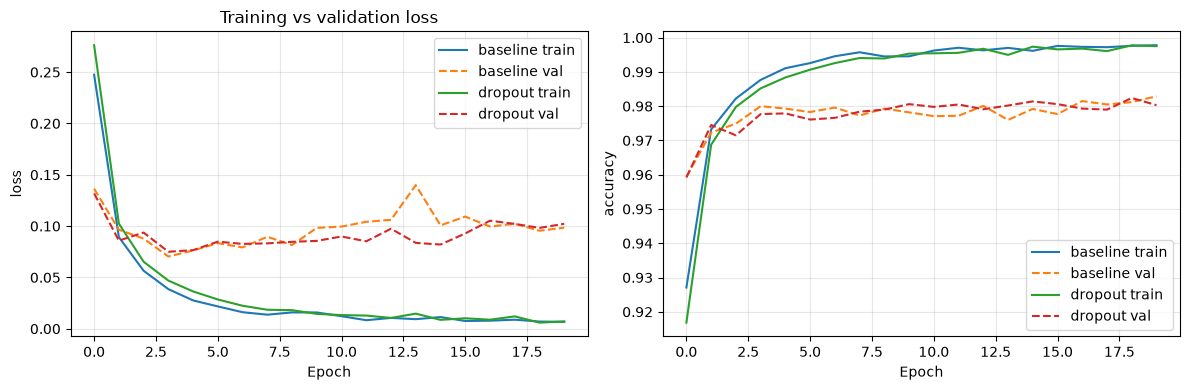

In [7]:
def plot_histories(histories, labels, metric="loss"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for hist, label in zip(histories, labels):
        axes[0].plot(hist.history[metric], label=f"{label} train")
        axes[0].plot(hist.history[f"val_{metric}"], linestyle="--", label=f"{label} val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel(metric)
    axes[0].legend()
    axes[0].set_title(f"Training vs validation {metric}")
    axes[0].grid(True, alpha=0.3)
    # accuracy panel
    for hist, label in zip(histories, labels):
        axes[1].plot(hist.history["accuracy"], label=f"{label} train")
        axes[1].plot(hist.history["val_accuracy"], linestyle="--", label=f"{label} val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories([history_baseline, history_dropout], ["baseline", "dropout"])

## 7. Confusion matrix

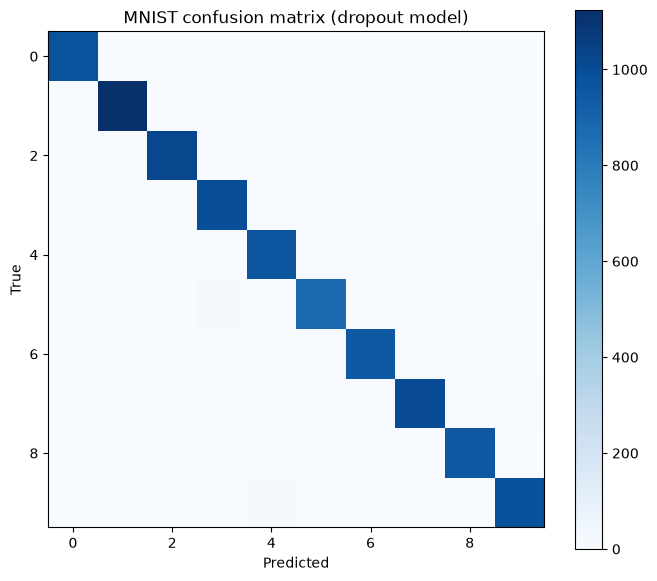

Worst confused pair (Moodle a2_worst_pair): 9-4 (11 errors)


In [8]:
y_pred = np.argmax(model_dropout.predict(x_test_flat, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("MNIST confusion matrix (dropout model)")
plt.show()

# TODO: find off-diagonal maximum → worst pair for Moodle a2_worst_pair
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
true_i, pred_j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
print(f"Worst confused pair (Moodle a2_worst_pair): {true_i}-{pred_j} ({cm_off[true_i, pred_j]} errors)")

## 8. Why sparse categorical crossentropy? (Moodle `a2_crossentropy`)

Write up to 150 words explaining:
- What integer labels look like vs one-hot
- What the loss computes
- Why this pairs with a softmax output

*Your answer here.*
  Sparse categorical crossentropy is suitable because the MNIST labels are simple integers from 0 to 9. The model uses softmax to produce a probability for each of the ten possible classes. This loss function checks the probability given to the correct class. If the model gives the correct class a high probability, the loss is small. If it gives the correct class a low probability, the loss is large. It works directly with integer labels, so there is no need to convert the labels into one-hot encoded vectors.